# MaldiAMRKit - Differential Analysis

This notebook demonstrates the `maldiamrkit.differential` module for identifying
m/z bins that differ significantly between **resistant (R)** and **susceptible (S)**
groups, and for comparing significant peaks across multiple drugs.

It covers:
- `DifferentialAnalysis` on a binned feature matrix (Mann-Whitney U or Welch's t-test)
- Multiple-testing correction (FDR-BH, FDR-BY, Bonferroni), log2 fold change, Cohen's d
- Ranking peaks with `top_peaks()` and filtering with `significant_peaks()`
- AMR-aware plots: `plot_volcano`, `plot_manhattan`
- Multi-drug comparison via `compare_drugs` + `plot_drug_comparison` (heatmap / UpSet)

## Dataset

These notebooks use the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)), a curated archive of MALDI-TOF spectra of *Klebsiella* clinical isolates from three Italian centres (Rome, Milan, Catania) with Amikacin / Meropenem resistance annotations. For simplicity we restrict the demo to the **Rome sub-cohort** (single site, no batch correction needed). The helper in [`notebooks/_demo.py`](_demo.py) caches the 370 MB tarball under `~/.cache/maldiamrkit/` (or `$MALDIAMRKIT_CACHE_DIR`) on first use.

## Load the Dataset

We load the Rome cohort and use `LabelEncoder(intermediate='drop')` to
build a binary label vector. The Zenodo dataset also ships a Meropenem
annotation, which we will use later for the multi-drug comparison.

In [1]:
import pathlib
import sys

import pandas as pd

from maldiamrkit.susceptibility import LabelEncoder

sys.path.insert(0, str(pathlib.Path.cwd()))  # _demo.py sits next to this notebook
from _demo import load_maldi_kleb_ai

ds = load_maldi_kleb_ai(antibiotic="Amikacin", verbose=True)
encoder = LabelEncoder(intermediate="nan")  # map 'I' to NaN so lengths stay aligned
y = (
    pd.Series(
        encoder.fit_transform(ds.meta["Amikacin"]),
        index=ds.meta.index,
        name="Amikacin",
    )
    .dropna()
    .astype(int)
)
X = ds.X.loc[y.index]
print(f"X shape: {X.shape}")
print(f"Class counts: {y.value_counts().to_dict()}")

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Processing spectra:   0%|          | 0/472 [00:00<?, ?spectrum/s]


Processing spectra:  98%|█████████▊| 464/472 [00:00<00:00, 4632.35spectrum/s]


Processing spectra: 100%|██████████| 472/472 [00:00<00:00, 4600.71spectrum/s]

X shape: (470, 6000)
Class counts: {1: 273, 0: 197}


## Run the Differential Analysis

Instantiate `DifferentialAnalysis` with `X` and `y` and call `.run()`.
The default test is Mann-Whitney U (non-parametric, recommended for MALDI peak
intensities) with Benjamini-Hochberg FDR correction.

In [2]:
from maldiamrkit.differential import DifferentialAnalysis

analysis = DifferentialAnalysis(X, y).run(
    test="mann_whitney",
    correction="fdr_bh",
)
analysis.results.sort_values("adjusted_p_value", ascending=True).head()

,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
904,4712.0,0.000492,0.000161,1.611970,1.031418e-07,0.000155,0.472830
905,4715.0,0.000506,0.000162,1.642962,3.811623e-08,0.000155,0.546662
901,4703.0,0.000284,0.000120,1.241332,7.021650e-08,0.000155,0.522023
3038,11114.0,0.000125,0.000080,0.652812,8.531360e-08,0.000155,0.589519
3037,11111.0,0.000102,0.000067,0.604420,1.692839e-07,0.000197,0.545698


The `results` table has one row per m/z bin with:

- `mz_bin` - the bin label (m/z value as stored in `X.columns`)
- `mean_r`, `mean_s` - mean intensity in each group
- `fold_change` - `log2((mean_r + eps) / (mean_s + eps))`
- `p_value` - raw test p-value
- `adjusted_p_value` - p-value after multiple-testing correction
- `effect_size` - Cohen's d between the two groups

### Construct directly from a `MaldiSet`

When the antibiotic column already stores numeric binary labels
(`0` / `1`), you can skip the manual `X` / `y` extraction:

```python
analysis = DifferentialAnalysis.from_maldi_set(
    ds.maldi_set, antibiotic='Amikacin'
).run()
```

In our case the labels are the strings `'R'` / `'S'`, so we keep the
explicit `LabelEncoder` step above.

In [3]:
print(f"{len(analysis.results)} bins tested")
print(f"Smallest adjusted p-value: {analysis.results['adjusted_p_value'].min():.3e}")
print(f"#adj <= 0.05: {(analysis.results['adjusted_p_value'] <= 0.05).sum()}")

6000 bins tested
Smallest adjusted p-value: 1.547e-04
#adj <= 0.05: 22


### Top Peaks and Significance Filtering

In [4]:
analysis.top_peaks(n=10)

,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
901,4703.0,0.000284,0.000120,1.241332,7.021650e-08,0.000155,0.522023
904,4712.0,0.000492,0.000161,1.611970,1.031418e-07,0.000155,0.472830
905,4715.0,0.000506,0.000162,1.642962,3.811623e-08,0.000155,0.546662
3038,11114.0,0.000125,0.000080,0.652812,8.531360e-08,0.000155,0.589519
3036,11108.0,0.000123,0.000083,0.562401,2.293709e-07,0.000197,0.518235
3037,11111.0,0.000102,0.000067,0.604420,1.692839e-07,0.000197,0.545698
3039,11117.0,0.000127,0.000083,0.604224,2.099257e-07,0.000197,0.558619
902,4706.0,0.000376,0.000140,1.430031,4.248146e-07,0.000319,0.491018
900,4700.0,0.000243,0.000120,1.017319,7.629639e-07,0.000509,0.442172
903,4709.0,0.000417,0.000150,1.470420,2.874043e-06,0.001724,0.464538


In [5]:
sig = analysis.significant_peaks(fc_threshold=1.0, p_threshold=0.05)
print(f"{len(sig)} peaks survive |log2FC| >= 1 and adj.p <= 0.05")
sig.head(10)

8 peaks survive |log2FC| >= 1 and adj.p <= 0.05


,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
0,4526.0,0.000472,0.000097,2.282285,4.044768e-05,0.014276,0.394177
1,4700.0,0.000243,0.000120,1.017319,7.629639e-07,0.000509,0.442172
2,4703.0,0.000284,0.000120,1.241332,7.021650e-08,0.000155,0.522023
3,4706.0,0.000376,0.000140,1.430031,4.248146e-07,0.000319,0.491018
4,4709.0,0.000417,0.000150,1.470420,2.874043e-06,0.001724,0.464538
5,4712.0,0.000492,0.000161,1.611970,1.031418e-07,0.000155,0.472830
6,4715.0,0.000506,0.000162,1.642962,3.811623e-08,0.000155,0.546662
7,4718.0,0.000366,0.000140,1.388156,1.361776e-05,0.006809,0.524848


## Volcano Plot

`plot_volcano` shows log2 fold change on the x axis and -log10(adjusted p-value)
on the y axis. Points are coloured by direction:

- red: up in resistant (`fold_change > fc_threshold` and `adj.p <= p_threshold`)
- blue: up in susceptible (`fold_change < -fc_threshold` and `adj.p <= p_threshold`)
- grey: non-significant

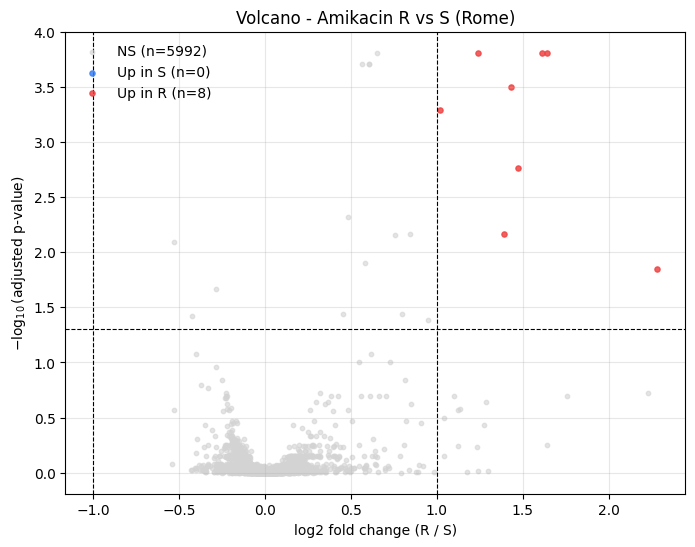

In [6]:
from maldiamrkit.differential import plot_volcano

_ = plot_volcano(
    analysis.results,
    fc_threshold=1.0,
    p_threshold=0.05,
    title="Volcano - Amikacin R vs S (Rome)",
)

## Manhattan Plot along the m/z Axis

`plot_manhattan` places each bin at its m/z position and plots
-log10(adjusted p-value). Points above the dashed line pass the
significance threshold.

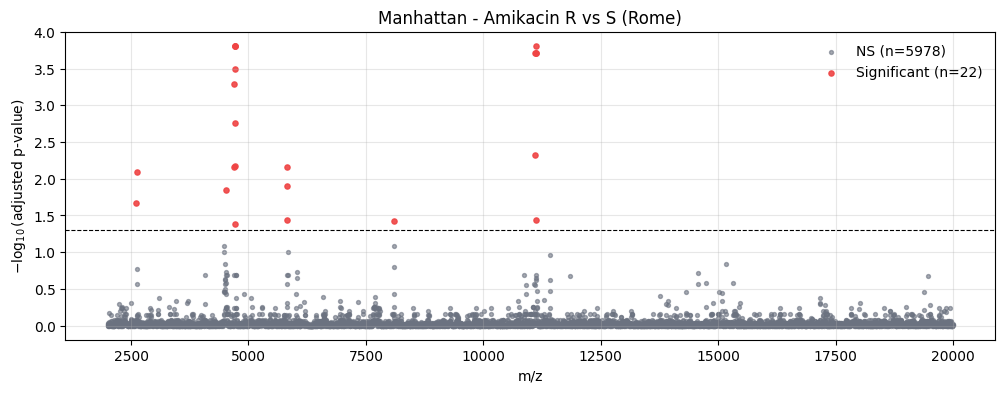

In [7]:
from maldiamrkit.differential import plot_manhattan

_ = plot_manhattan(
    analysis.results,
    p_threshold=0.05,
    title="Manhattan - Amikacin R vs S (Rome)",
)

## Compare across Multiple Drugs

`DifferentialAnalysis.compare_drugs` returns a boolean matrix whose rows are
the **union of significant m/z bins** across all drugs and whose columns are
drug names. `True` means the peak is significant for that drug.

We use the two antimicrobials annotated in MALDI-Kleb-AI - Amikacin and
Meropenem - which share isolates but have different resistance mechanisms,
so the overlap between their significant-peak sets is interesting on its
own merits.

In [8]:
ds_mero = load_maldi_kleb_ai(antibiotic="Meropenem", verbose=False)
encoder_nan = LabelEncoder(intermediate="nan")
y_mero = (
    pd.Series(
        encoder_nan.fit_transform(ds_mero.meta["Meropenem"]),
        index=ds_mero.meta.index,
        name="Meropenem",
    )
    .dropna()
    .astype(int)
)
X_mero = ds_mero.X.loc[y_mero.index]

analysis_amk = DifferentialAnalysis(X, y).run()
analysis_mer = DifferentialAnalysis(X_mero, y_mero).run()

comparison = DifferentialAnalysis.compare_drugs(
    {"Amikacin": analysis_amk, "Meropenem": analysis_mer},
    fc_threshold=1.0,
    p_threshold=0.05,
)
print(f"Union of significant bins: {len(comparison)}")
print("Per-drug counts:")
print(comparison.sum())

Union of significant bins: 14
Per-drug counts:
Amikacin      8
Meropenem    13
dtype: int64


### Boolean Heatmap

`plot_drug_comparison(..., kind='heatmap')` renders a compact peaks x drugs
matrix - useful for spotting drug-specific peaks at a glance.

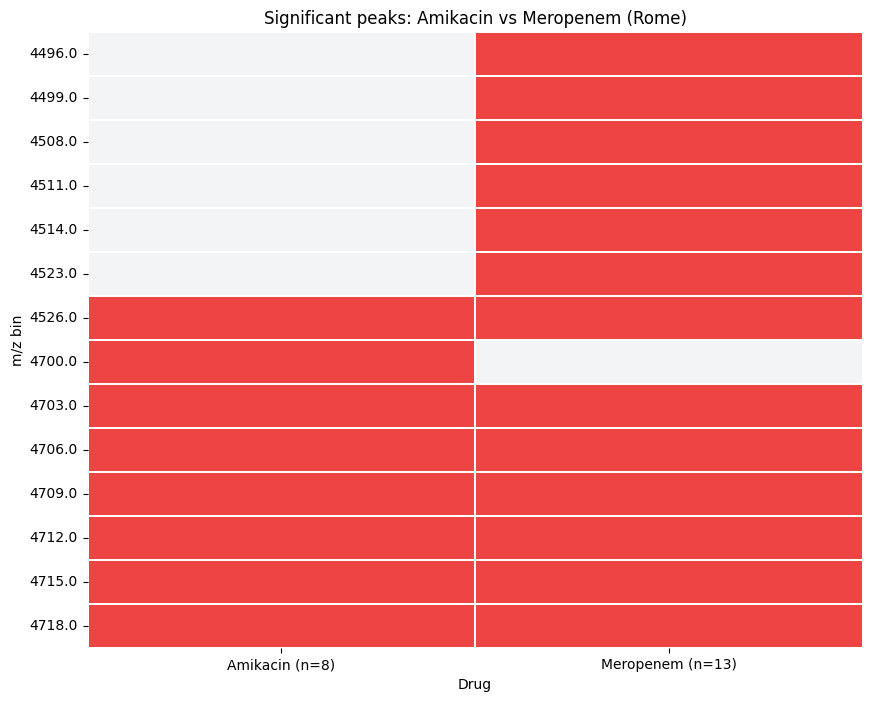

In [9]:
from maldiamrkit.differential import plot_drug_comparison

_ = plot_drug_comparison(
    comparison,
    kind="heatmap",
    title="Significant peaks: Amikacin vs Meropenem (Rome)",
)

### UpSet-style Intersection Plot

With more drugs, a Venn diagram stops scaling - an UpSet plot shows
the size of every intersection of significant-peak sets.

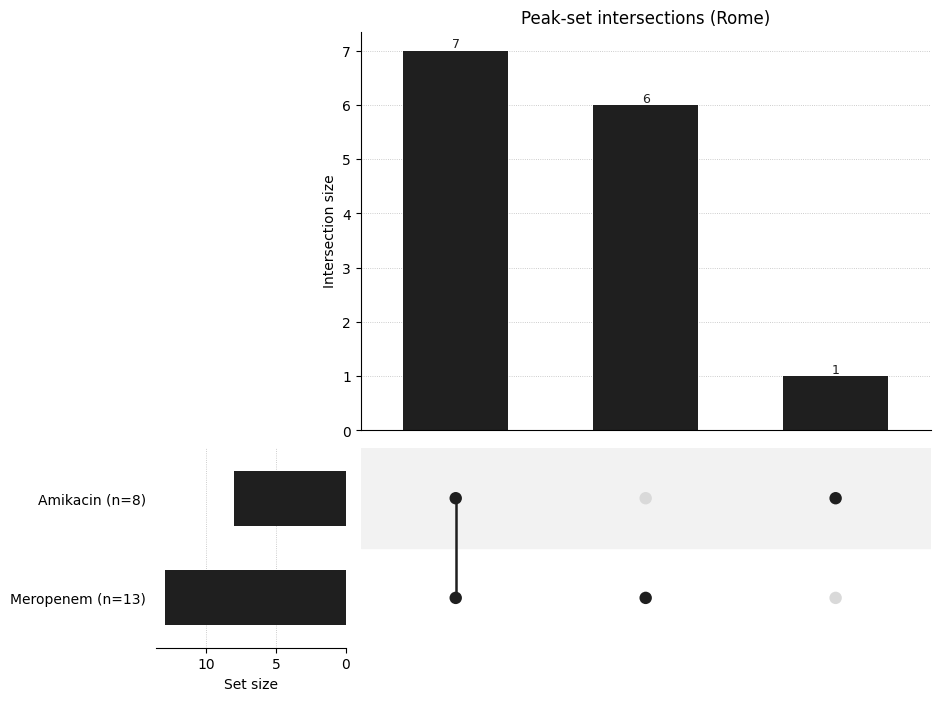

In [10]:
_ = plot_drug_comparison(
    comparison,
    kind="upset",
    title="Peak-set intersections (Rome)",
)

## Choosing a Test and Correction

`DifferentialAnalysis.run()` accepts both plain strings and the `StatisticalTest` / `CorrectionMethod`.

`StatisticalTest` enums:

| `test`           | When to use                                                          |
| ---------------- | -------------------------------------------------------------------- |
| `mann_whitney`   | Default. Non-parametric, robust to MALDI intensity distributions.    |
| `t_test`         | Welch's t-test (unequal variances). Use for approximately-Gaussian data. |

`CorrectionMethod` enums:

| `correction`   | Meaning                                                          |
| -------------- | ---------------------------------------------------------------- |
| `fdr_bh`       | Benjamini-Hochberg FDR. Good default.                             |
| `fdr_by`       | Benjamini-Yekutieli FDR. More conservative under dependence.      |
| `bonferroni`   | Family-wise error control. Most conservative.                     |

Example of a conservative configuration:

In [11]:
analysis_strict = DifferentialAnalysis(X, y).run(
    test="t_test",
    correction="bonferroni",
)
analysis_strict.top_peaks(n=5)

,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
3038,11114.0,0.000125,0.000080,0.652812,2.290201e-11,1.374120e-07,0.589519
905,4715.0,0.000506,0.000162,1.642962,9.656653e-11,5.793992e-07,0.546662
3039,11117.0,0.000127,0.000083,0.604224,2.661767e-10,1.597060e-06,0.558619
901,4703.0,0.000284,0.000120,1.241332,4.082946e-10,2.449768e-06,0.522023
3037,11111.0,0.000102,0.000067,0.604420,4.436762e-10,2.662057e-06,0.545698


## Optional: Scoping Filters

When you already know which m/z regions matter, or you want to limit the
hypothesis burden, pass `mz_ranges` and/or `peak_detector` to `run()`:

In [12]:
from maldiamrkit.detection import MaldiPeakDetector

scoped = DifferentialAnalysis(X, y).run(
    mz_ranges=[(3000, 6000), (9000, 12000)],
    peak_detector=MaldiPeakDetector(method="local", binary=True, prominence=1e-4),
)
print(f"Bins tested (scoped):   {len(scoped.results)}")
print(f"Bins tested (full run): {len(analysis.results)}")
print(f"#adj <= 0.05 (scoped):  {(scoped.results['adjusted_p_value'] <= 0.05).sum()}")

Bins tested (scoped):   1994
Bins tested (full run): 6000
#adj <= 0.05 (scoped):  23


## See Also

- [API Reference - Differential](https://maldiamrkit.readthedocs.io/en/latest/api/differential.html)
- [Exploration notebook](05_exploration.ipynb) for PCA, t-SNE, UMAP, and spectral similarity